<a href="https://colab.research.google.com/github/Amogh-S-Acharya/ML2-AMOGH_S_ACHARYA-4NI23CI012/blob/main/bagging_and_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:

iris = load_iris()

X = iris.data
y = iris.target

print("Features:", X.shape)
print("Target:", y.shape)


Features: (150, 4)
Target: (150,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)



Training data: (120, 4)
Testing data: (30, 4)


In [7]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=10,
    random_state=42
)


In [8]:
bagging_model.fit(X_train, y_train)

y_pred_bagging = bagging_model.predict(X_test)

bagging_accuracy = accuracy_score(y_test, y_pred_bagging)

print("Bagging Accuracy:", bagging_accuracy)
print("\nBagging Classification Report:")
print(classification_report(y_test, y_pred_bagging))



Bagging Accuracy: 0.9666666666666667

Bagging Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [9]:


boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=10,
    random_state=42
)

boosting_model.fit(X_train, y_train)

y_pred_boosting = boosting_model.predict(X_test)

boosting_accuracy = accuracy_score(y_test, y_pred_boosting)

print("Boosting Accuracy:", boosting_accuracy)
print("\nBoosting Classification Report:")
print(classification_report(y_test, y_pred_boosting))



results = pd.DataFrame({
    "Model": ["Bagging", "Boosting"],
    "Accuracy": [bagging_accuracy, boosting_accuracy]
})


Boosting Accuracy: 0.9333333333333333

Boosting Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



/tmp/ipykernel_495/702832235.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')


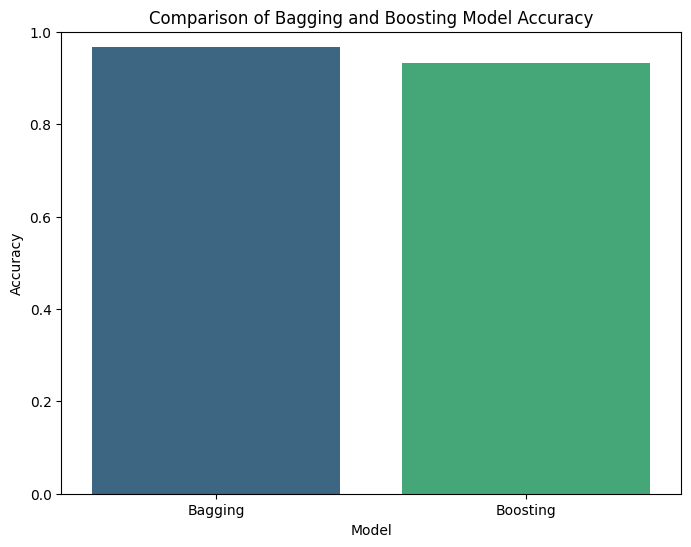

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
plt.title('Comparison of Bagging and Boosting Model Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.show()